# 03 — RL Agent Training Tutorial
**(Notebook 3 / 5 — requires `01_dataset_generation.ipynb` to be run first)**

This notebook guides you through training a reinforcement learning agent to learn quantum noise models.

**Outputs written by this notebook:**
- `agents/1q/model.zip` — trained 1-qubit agent
- `agents/3q/model.zip` — trained 3-qubit agent
- `results/training/1q/history.npz` — 1-qubit training history
- `results/training/3q/history.npz` — 3-qubit training history
- `results/training/3q/config.json` — 3-qubit experiment configuration

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch

# Import RL Noise components
from rlnoise.config import (
    DatasetConfig,
    NoiseConfig,
    GateSpecificNoise,
    GymEnvConfig,
    RewardConfig,
    AgentConfig,
)
from rlnoise.dataset import DatasetGenerator, CircuitDataset
from rlnoise.circuit_encoder import CircuitEncoder
from rlnoise.gym_env import QuantumCircuitEnv
from rlnoise.rl_agent import RLAgent

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


## 2. Understanding the Training Components

Before we start training, let's understand the key components:

### 2.1 Neural Network Architecture

The agent uses a **CNN Feature Extractor** that processes the sliding window observations:
- **Input**: Sliding window of circuit moments (shape: encoding_dim × n_qubits × kernel_size)
- **Conv2D Layer**: Extracts spatial features from the circuit
- **Flatten + Linear**: Maps features to a fixed dimension
- **Policy & Value Networks**: Separate networks for action selection and value estimation

### 2.2 Training Callback

The callback monitors training progress:
- Periodically evaluates the agent on train/validation sets
- Tracks metrics (reward, trace distance, etc.)
- Saves the best model based on validation performance
- Provides real-time feedback during training

### 2.3 Agent Configuration

The `AgentConfig` controls:
- **features_dim**: Output dimension of feature extractor
- **filter_size**: CNN filter width
- **n_filters**: Number of CNN filters
- **n_steps**: Steps before PPO update
- **batch_size**: Batch size for training
- **learning_rate**: Optimizer learning rate

## 3. Simple Training Example: Single Circuit

Let's start with the simplest possible case: a single 1-qubit circuit with only one source of coherent noise.

### 3.1. Create a Simple Dataset

In [2]:
# Create a very simple dataset - 1 circuit, 1 qubit
simple_dataset_config = DatasetConfig(
    n_circuits=1,
    moments=8,
    qubits=1,
    primitive_gates=["rx", "rz"],
    clifford=True
)

noise_parameter = 0.06  # coherent noise level for the simple model

# Simple noise model - only depolarizing with a clear value
simple_noise_config = NoiseConfig(
    noise_list=[
        GateSpecificNoise(gate="rx", noise_channel="coherent_x", noise_parameter=noise_parameter),
        GateSpecificNoise(gate="rz", noise_channel="coherent_x", noise_parameter=noise_parameter),
    ]
)

# Generate the dataset
generator = DatasetGenerator(simple_dataset_config, simple_noise_config)
simple_dataset = generator.generate(verbose=True)

print(simple_dataset)

[Qibo 0.2.23|INFO|2026-04-21 08:34:30]: Using numpy backend on /CPU:0


Generating 1 circuits...
Applying noise model...
Encoding circuits...
Dataset generated.

  CircuitDataset
    - Circuits:            1
    - Qubits:              1
    - Moments (depth):     8
    - Encoding dimension:  8
    - Circuit shape:       (8, 1, 8)


### 3.2. Create Environment and Encoder

In [3]:
# Create encoder
simple_encoder = CircuitEncoder(primitive_gates=["rx", "rz"])

# Environment configuration
simple_env_config = GymEnvConfig(
    kernel_size=3,
    action_space_max_value=0.1,     # Max noise per step: 0.1
    val_split=0.0,              # No validation split for single circuit
)

# Reward configuration
simple_reward_config = RewardConfig(
    metric="trace",
    function="inverted_squared",
    alpha=20.0
)

# Create environment
simple_env = QuantumCircuitEnv(
    dataset=simple_dataset,
    encoder=simple_encoder,
    env_config=simple_env_config,
    reward_config=simple_reward_config,
)

print(simple_env)

QuantumCircuitEnv:
  Dataset:
    circuits: 1 (1 train, 0 val)
    qubits: 1
  Encoder:
    primitive_gates: ['rx', 'rz']
  Environment:
    observation_space: (8, 1, 3)
    action_space: (1, 4)
    kernel_size: 3
    action_max: 0.1
    only_depolarizing: False
  Reward:
    metric: trace
    function: inverted_squared
    alpha: 20.0


### 3.3. Configure the Agent

For this simple task, we'll use a small neural network.

In [4]:
# Agent configuration - small network for simple task
simple_agent_config = AgentConfig(
    policy="MlpPolicy",
    features_dim=32,        # Number of features extracted by CNN
    filter_size=2,          # Size of convolutional filters
    n_filters=16,           # Number of filters
    pi_net_arch=[32],       # Simple policy network
    vf_net_arch=[32],       # Simple value network
    n_steps=400,            # Update every 400 steps
    batch_size=50,          # Small batches (has to divide steps)
    learning_rate=1e-4,
    verbose=1
)

simple_agent = RLAgent(
    env=simple_env,
    agent_config=simple_agent_config
)

print(simple_agent)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RLAgent (PPO)
  Observation space:    (8, 1, 3)
  Action space:         (1, 4)
  Action range:         [0.000, 1.000]
------------------------------------------------------------
  Total parameters:     3,609
  Trainable parameters: 3,609
------------------------------------------------------------
  Features dim:         32
  CNN filters:          16
  CNN filter size:      2
  Policy net arch:      [32]
  Value net arch:       [32]
------------------------------------------------------------
  Learning rate:        0.0001
  Batch size:           50
  N steps:              400
  Gamma:                0.99


For more information about the neural network:

In [5]:
simple_agent.print_network()

NEURAL NETWORK ARCHITECTURE

ActorCriticPolicy(
  (features_extractor): CNNFeaturesExtractor(
    (conv1): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
    (cnn): Sequential(
      (0): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
      (1): ReLU()
      (2): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): ReLU()
    )
  )
  (pi_features_extractor): CNNFeaturesExtractor(
    (conv1): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
    (cnn): Sequential(
      (0): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
      (1): ReLU()
      (2): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
      (1): ReLU()
    )
  )
  (vf_features_extractor): CNNFeaturesExtractor(
    (conv1): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
    (cnn): Sequential(
      (0): Conv2d(8, 16, kernel_size=(1, 2), stride=(1, 1))
     

### 3.4. Train the Agent

Now let's create the agent and train it!

In [6]:
import importlib, rlnoise.callback, rlnoise.rl_agent
importlib.reload(rlnoise.callback)
importlib.reload(rlnoise.rl_agent)
from rlnoise.rl_agent import RLAgent

# Re-create agent to pick up reloaded modules
simple_agent = RLAgent(env=simple_env, agent_config=simple_agent_config)

# Train the agent
results = simple_agent.train(
    total_timesteps=30001,           # Short training for simple task
    check_freq=2000,                 # Performance evaluation frequency (in steps)
    save_best=True,                 # Don't save for this demo
    progress_bar=True,
    verbose=True,                    # Print avg reward at each eval step
    deterministic_train_eval=True,   # Full deterministic pass over train set (False = faster rollout accumulation)
)


Output()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Step    2000 | Train reward: 28.8589 ± 0.0000  trace_dist: 0.0416 ± 0.0000  fidelity: 0.9983 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace_dist: 0.0000 ± 0.0000  fidelity: 0.0000 ± 0.0000


Step    4000 | Train reward: 27.9114 ± 0.0000  trace_dist: 0.0423 ± 0.0000  fidelity: 0.9982 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace_dist: 0.0000 ± 0.0000  fidelity: 0.0000 ± 0.0000


Step    6000 | Train reward: 30.4662 ± 0.0000  trace_dist: 0.0405 ± 0.0000  fidelity: 0.9984 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace_dist: 0.0000 ± 0.0000  fidelity: 0.0000 ± 0.0000


...

Step   24000 | Train reward: 27.9114 ± 0.0000  trace_dist: 0.0423 ± 0.0000  fidelity: 0.9982 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace_dist: 0.0000 ± 0.0000  fidelity: 0.0000 ± 0.0000


Step   26000 | Train reward: 31.1580 ± 0.0000  trace_dist: 0.0401 ± 0.0000  fidelity: 0.9984 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace_dist: 0.0000 ± 0.0000  fidelity: 0.0000 ± 0.0000


Step   28000 | Train reward: 29.8315 ± 0.0000  trace_dist: 0.0409 ± 0.0000  fidelity: 0.9983 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace_dist: 0.0000 ± 0.0000  fidelity: 0.0000 ± 0.0000


Step   30000 | Train reward: 35.0976 ± 0.0000  trace_dist: 0.0377 ± 0.0000  fidelity: 0.9986 ± 0.0000  |  Val reward: 0.0000 ± 0.0000  trace_dist: 0.0000 ± 0.0000  fidelity: 0.0000 ± 0.0000


Loaded best model weights.


### 3.5. Analyze Training Results

The error bars are not shown as only one sample is available

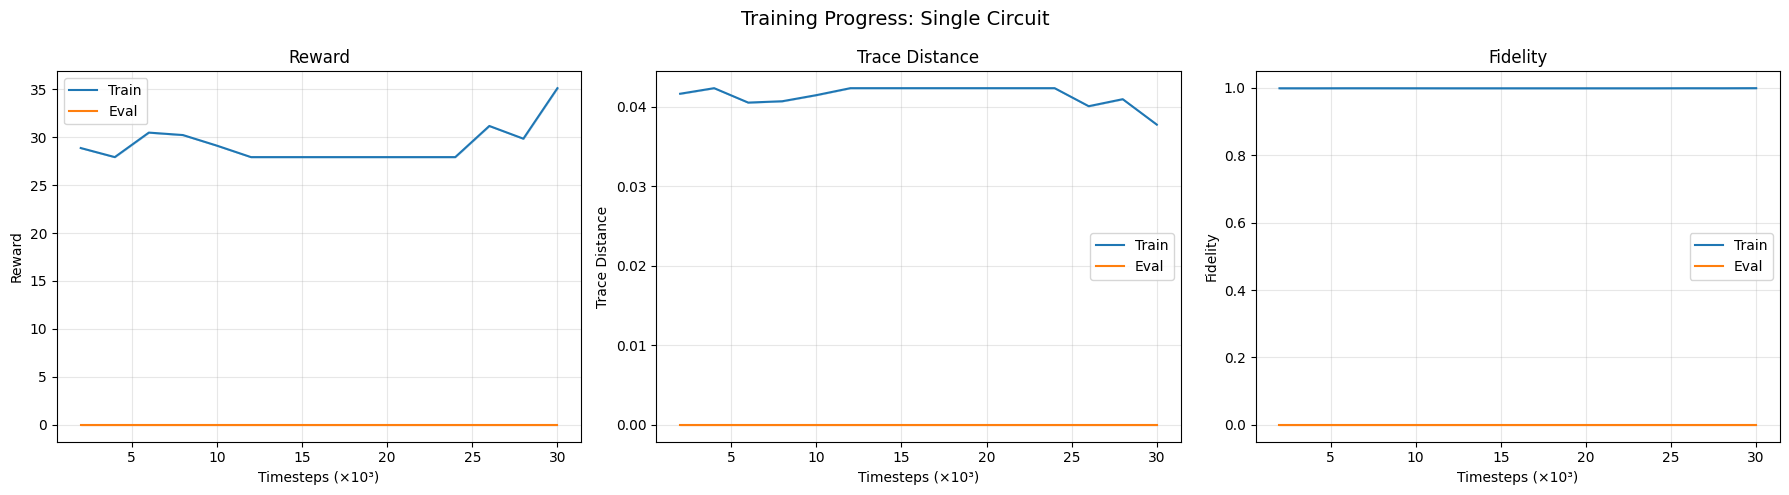

In [ ]:
from rlnoise.visualization import plot_training_dashboard

fig = plot_training_dashboard(
    results,
    title="Training Progress: Single Circuit",
    filepath=None,
    show_reward=True,
    show_trace_distance=True,
    show_fidelity=True,
)
plt.show()


### 3.6. Test the Trained Agent

Let's see what noise parameters the agent learned to apply!

In [8]:
# Reset environment and run an episode with the trained agent
obs, info = simple_env.reset()

actions_taken = []
step = 0
terminated = False

print("Target noise: ", noise_parameter)
print()

while not terminated:
    # Get action from trained agent
    action = simple_agent.predict(obs, deterministic=True)
    actions_taken.append(action)
    
    # Show what action was taken
    
    x_action = action[0, 0]  # Index 0 is coherent X
    print(f"Step {step}: Coherent rx action = {x_action:.4f} → noise = {x_action * 0.1:.4f}")

    print("Full action:\n", action)
    
    # Take step
    obs, reward, terminated, truncated, info = simple_env.step(action)
    step += 1

Target noise:  0.06

Step 0: Coherent rx action = 0.0000 → noise = 0.0000
Full action:
 [[0.         0.14098518 0.         0.        ]]
Step 1: Coherent rx action = 0.0000 → noise = 0.0000
Full action:
 [[0.        0.1422128 0.        0.       ]]
Step 2: Coherent rx action = 0.0000 → noise = 0.0000
Full action:
 [[0.         0.14118329 0.         0.        ]]
Step 3: Coherent rx action = 0.0000 → noise = 0.0000
Full action:
 [[0.         0.14171512 0.         0.        ]]
Step 4: Coherent rx action = 0.0000 → noise = 0.0000
Full action:
 [[0.         0.14192457 0.         0.        ]]
Step 5: Coherent rx action = 0.0000 → noise = 0.0000
Full action:
 [[0.         0.14194043 0.         0.        ]]
Step 6: Coherent rx action = 0.0000 → noise = 0.0000
Full action:
 [[0.         0.14111648 0.         0.        ]]
Step 7: Coherent rx action = 0.0000 → noise = 0.0000
Full action:
 [[0.         0.13973929 0.         0.        ]]


## 4. Training with Multiple Circuits

Now let's scale up to multiple circuits to see how the agent generalizes.

### 4.1. Load 1-Qubit Dataset

Loads the canonical 1-qubit dataset from `datasets/dataset_1q.npz`.
**Run `01_dataset_generation.ipynb` (Section 4) first** if the file does not exist.

In [9]:
from pathlib import Path

DATASET_1Q_PATH = Path("datasets/dataset_1q.npz")
if not DATASET_1Q_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATASET_1Q_PATH}'.\n"
        "Please run '01_dataset_generation.ipynb' (Section 4) first."
    )

multi_dataset = CircuitDataset.load(str(DATASET_1Q_PATH))
print(f"Loaded 1-qubit dataset from '{DATASET_1Q_PATH}'")
print(multi_dataset)

# Noise model from experiments/1qubit/config.json
multi_noise_config = NoiseConfig(
    noise_list=[
        GateSpecificNoise(gate="rz", noise_channel="depolarizing",  noise_parameter=0.02),
        GateSpecificNoise(gate="rx", noise_channel="damping",        noise_parameter=0.03),
        GateSpecificNoise(gate="rx", noise_channel="coherent_x",     noise_parameter=0.04),
        GateSpecificNoise(gate="rz", noise_channel="coherent_z",     noise_parameter=0.02),
    ]
)

Loaded 1-qubit dataset from 'datasets\dataset_1q.npz'

  CircuitDataset
    - Circuits:            100
    - Qubits:              1
    - Moments (depth):     10
    - Encoding dimension:  8
    - Circuit shape:       (10, 1, 8)


### 4.2. Setup Environment with Validation Split

In [10]:

multi_encoder = CircuitEncoder(primitive_gates=["rz", "rx"])

# Env config from 1q config.json
multi_env_config = GymEnvConfig(
    kernel_size=3,
    action_penalty=0.0,
    action_space_max_value=0.06,
    enable_only_depolarizing=False,
    val_split=0.2,
)

multi_reward_config = RewardConfig(
    metric="trace",
    function="inverted_squared",
    alpha=20.0,
)

multi_env = QuantumCircuitEnv(
    dataset=multi_dataset,
    encoder=multi_encoder,
    env_config=multi_env_config,
    reward_config=multi_reward_config,
)

print(multi_env)


QuantumCircuitEnv:
  Dataset:
    circuits: 100 (80 train, 20 val)
    qubits: 1
  Encoder:
    primitive_gates: ['rz', 'rx']
  Environment:
    observation_space: (8, 1, 3)
    action_space: (1, 4)
    kernel_size: 3
    action_max: 0.06
    only_depolarizing: False
  Reward:
    metric: trace
    function: inverted_squared
    alpha: 20.0


### 4.3. Train with Callback Monitoring

In [11]:
import os
os.makedirs("agents/1q", exist_ok=True)
os.makedirs("results/training/1q", exist_ok=True)

# Agent config from experiments/1qubit/config.json
multi_agent_config = AgentConfig(
    policy="MlpPolicy",
    features_dim=32,
    filter_size=1,
    n_filters=16,
    pi_net_arch=[32, 32],
    vf_net_arch=[32, 32],
    n_steps=1000,
    batch_size=200,
    learning_rate=1e-4,
)

multi_agent = RLAgent(env=multi_env, agent_config=multi_agent_config)
print(multi_agent)

multi_results = multi_agent.train(
    total_timesteps=200000,
    check_freq=2000,
    save_best=True,
    progress_bar=True,
    verbose=True,
    save_path="agents/1q/model",
    history_path="results/training/1q/history",
)

Output()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RLAgent (PPO)
  Observation space:    (8, 1, 3)
  Action space:         (1, 4)
  Action range:         [0.000, 1.000]
------------------------------------------------------------
  Total parameters:     6,105
  Trainable parameters: 6,105
------------------------------------------------------------
  Features dim:         32
  CNN filters:          16
  CNN filter size:      1
  Policy net arch:      [32, 32]
  Value net arch:       [32, 32]
------------------------------------------------------------
  Learning rate:        0.0001
  Batch size:           200
  N steps:              1000
  Gamma:                0.99


Step    2000 | Train reward: 3.2587 ± 0.8916  trace_dist: 0.1277 ± 0.0191  fidelity: 0.8823 ± 0.0150  |  Val reward: 3.2527 ± 0.9426  trace_dist: 0.1283 ± 0.0203  fidelity: 0.8815 ± 0.0168
Model saved in agents/1q/model


Step    4000 | Train reward: 3.2727 ± 0.8894  trace_dist: 0.1274 ± 0.0188  fidelity: 0.8824 ± 0.0149  |  Val reward: 3.2674 ± 0.9371  trace_dist: 0.1279 ± 0.0199  fidelity: 0.8816 ± 0.0168
Model saved in agents/1q/model


Step    6000 | Train reward: 3.2778 ± 0.8884  trace_dist: 0.1273 ± 0.0188  fidelity: 0.8824 ± 0.0149  |  Val reward: 3.2740 ± 0.9365  trace_dist: 0.1278 ± 0.0198  fidelity: 0.8817 ± 0.0168


...

Step  194000 | Train reward: 60.6559 ± 82.5878  trace_dist: 0.0386 ± 0.0146  fidelity: 0.9968 ± 0.0023  |  Val reward: 54.5036 ± 39.5289  trace_dist: 0.0344 ± 0.0087  fidelity: 0.9976 ± 0.0013


Step  196000 | Train reward: 45.5541 ± 53.9972  trace_dist: 0.0423 ± 0.0148  fidelity: 0.9961 ± 0.0026  |  Val reward: 41.4938 ± 23.9717  trace_dist: 0.0382 ± 0.0087  fidelity: 0.9969 ± 0.0016


Step  198000 | Train reward: 36.9746 ± 37.9689  trace_dist: 0.0453 ± 0.0149  fidelity: 0.9953 ± 0.0029  |  Val reward: 35.6739 ± 19.7532  trace_dist: 0.0409 ± 0.0090  fidelity: 0.9963 ± 0.0018


Step  200000 | Train reward: 36.2835 ± 31.3407  trace_dist: 0.0450 ± 0.0146  fidelity: 0.9951 ± 0.0030  |  Val reward: 36.2884 ± 23.1480  trace_dist: 0.0411 ± 0.0092  fidelity: 0.9960 ± 0.0019


Loaded best model weights from agents/1q/model
Training history saved to results/training/1q/history.npz


### 4.4. Analyze Multi-Circuit Training

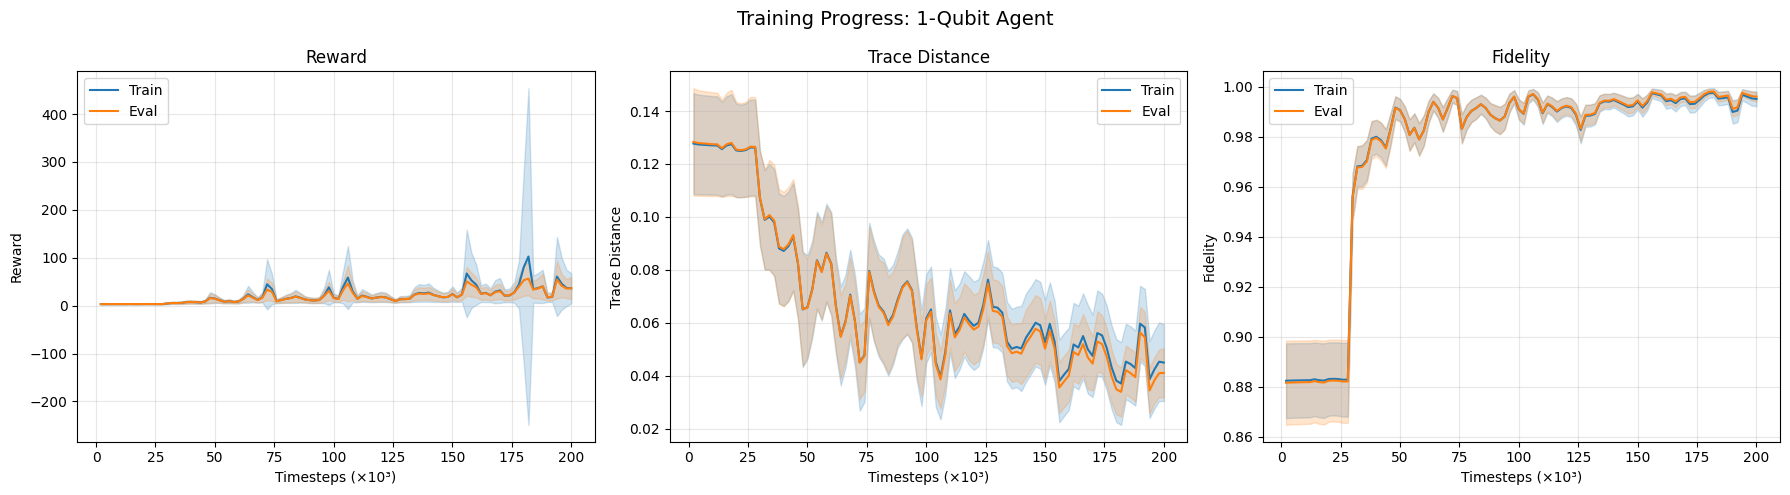

In [12]:
fig = plot_training_dashboard(
    multi_results,
    title="Training Progress: 1-Qubit Agent",
    filepath="results/training/1q/dashboard.png",
    show_reward=True,
    show_trace_distance=True,
    show_fidelity=True,
)
plt.show()

### 4.5. Evaluation on Non-Clifford Test Circuits

After training on (mostly) Clifford circuits we run a **held-out evaluation** on freshly generated non-Clifford random circuits — the same protocol used in the original paper. This measures how well the agent generalises to circuits it has never seen during training.

In [13]:
from rlnoise.benchmarking import evaluate_on_dataset

# ── Parameters — adjust as needed ────────────────────────────────────────────
EVAL_N_CIRCUITS = 50    # number of non-Clifford test circuits
EVAL_DEPTH      = 10    # circuit depth (moments)

# ── Generate fresh non-Clifford test circuits ─────────────────────────────────
from rlnoise.config import DatasetConfig
from rlnoise.dataset import DatasetGenerator

eval_dataset_config = DatasetConfig(
    n_circuits=EVAL_N_CIRCUITS,
    moments=EVAL_DEPTH,
    qubits=1,
    primitive_gates=["rz", "rx"],
    clifford=False,       # non-Clifford — not seen during training
    mixed=False,
)

eval_generator = DatasetGenerator(eval_dataset_config, multi_noise_config)
eval_dataset_1q = eval_generator.generate(verbose=False)
print(f"Generated {EVAL_N_CIRCUITS} non-Clifford evaluation circuits (depth={EVAL_DEPTH})")

# ── Run evaluation ─────────────────────────────────────────────────────────────
eval_results_1q = evaluate_on_dataset(
    rl_agent=multi_agent,
    circuits=eval_dataset_1q.circuits,
    labels=eval_dataset_1q.labels,
    verbose=True,
)

Generated 50 non-Clifford evaluation circuits (depth=10)
  Evaluating circuit 1/50…
  Evaluating circuit 6/50…
  Evaluating circuit 11/50…
  Evaluating circuit 16/50…
  Evaluating circuit 21/50…
  Evaluating circuit 26/50…
  Evaluating circuit 31/50…
  Evaluating circuit 36/50…
  Evaluating circuit 41/50…
  Evaluating circuit 46/50…

  Evaluation Results (non-Clifford test set)
  Circuits evaluated : 50
  Fidelity           : 0.9968 ± 0.0031
  Trace distance     : 0.0419 ± 0.0190
  MSE                : 0.001059 ± 0.000916


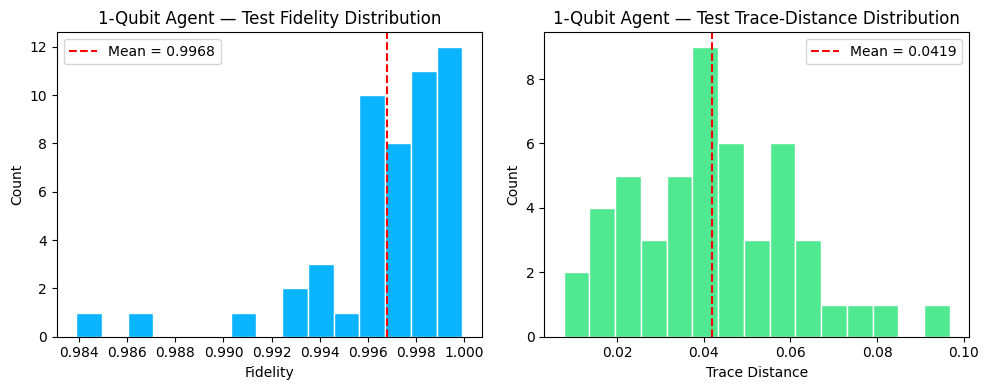

In [14]:
fidelities_1q  = [r["fidelity"]        for r in eval_results_1q["per_circuit"]]
trace_dists_1q = [r["trace_distance"]  for r in eval_results_1q["per_circuit"]]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(fidelities_1q, bins=15, color="#0bb4ff", edgecolor="white")
axes[0].axvline(eval_results_1q["mean_fidelity"], color="red", linestyle="--",
                label=f"Mean = {eval_results_1q['mean_fidelity']:.4f}")
axes[0].set_xlabel("Fidelity")
axes[0].set_ylabel("Count")
axes[0].set_title("1-Qubit Agent — Test Fidelity Distribution")
axes[0].legend()

axes[1].hist(trace_dists_1q, bins=15, color="#50e991", edgecolor="white")
axes[1].axvline(eval_results_1q["mean_trace_distance"], color="red", linestyle="--",
                label=f"Mean = {eval_results_1q['mean_trace_distance']:.4f}")
axes[1].set_xlabel("Trace Distance")
axes[1].set_ylabel("Count")
axes[1].set_title("1-Qubit Agent — Test Trace-Distance Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/training/1q/eval_distributions.png", dpi=150)
plt.show()

## 5. Advanced: 3-Qubit Training

Now for the final challenge - training on 3-qubit circuits with multiple noise types!

### 5.1. Load 3-Qubit Dataset

Loads the canonical 3-qubit dataset from `datasets/dataset_3q.npz`.
**Run `01_dataset_generation.ipynb` (Section 4) first** if the file does not exist.

In [4]:
DATASET_3Q_PATH = Path("datasets/dataset_3q.npz")
if not DATASET_3Q_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATASET_3Q_PATH}'.\n"
        "Please run '01_dataset_generation.ipynb' (Section 4) first."
    )

dataset_3q = CircuitDataset.load(str(DATASET_3Q_PATH))
print(f"Loaded 3-qubit dataset from '{DATASET_3Q_PATH}'")
print(dataset_3q)

# Noise model from experiments/3qubit/config.json (3q_high setup)
noise_config_3q = NoiseConfig(
    noise_list=[
        GateSpecificNoise(gate="rz", noise_channel="depolarizing",  noise_parameter=0.02),
        GateSpecificNoise(gate="cz", noise_channel="depolarizing",  noise_parameter=0.02),
        GateSpecificNoise(gate="rx", noise_channel="damping",        noise_parameter=0.03),
        GateSpecificNoise(gate="cz", noise_channel="damping",        noise_parameter=0.03),
        GateSpecificNoise(gate="rx", noise_channel="coherent_x",     noise_parameter=0.04),
        GateSpecificNoise(gate="rz", noise_channel="coherent_z",     noise_parameter=0.03),
    ]
)

Loaded 3-qubit dataset from 'datasets\dataset_3q.npz'

  CircuitDataset
    - Circuits:            800
    - Qubits:              3
    - Moments (depth):     31
    - Encoding dimension:  8
    - Circuit shape:       variable (sample: (31, 3, 8))


### 5.2. Setup 3-Qubit Environment

In [5]:
# Create encoder for 3-qubit circuits
encoder_3q = CircuitEncoder(primitive_gates=["rx", "rz", "cz"])

# Environment configuration
env_config_3q = GymEnvConfig(
    kernel_size=3,
    action_space_max_value=0.06,  # Max noise per step: 0.06
    val_split=0.2,
    enable_only_depolarizing=False,  # Allow all noise types
)

# Reward configuration
reward_config_3q = RewardConfig(
    metric="trace",
    function="inverted_squared",
    alpha=20.0
)

# Create environment
env_3q = QuantumCircuitEnv(
    dataset=dataset_3q,
    encoder=encoder_3q,
    env_config=env_config_3q,
    reward_config=reward_config_3q,
)

print(env_3q)

QuantumCircuitEnv:
  Dataset:
    circuits: 800 (640 train, 160 val)
    qubits: 3
  Encoder:
    primitive_gates: ['rx', 'rz', 'cz']
  Environment:
    observation_space: (8, 3, 3)
    action_space: (3, 4)
    kernel_size: 3
    action_max: 0.06
    only_depolarizing: False
  Reward:
    metric: trace
    function: inverted_squared
    alpha: 20.0


### 5.3. Configure Agent for 3-Qubit Circuits

For 3-qubit circuits, we need a larger network to handle the complexity.

In [11]:

# Agent config from 3q_high config.json:
#   policy=MlpPolicy, features_dim=64, filter_size=1, n_filters=32,
#   net_arch pi=[32,32] vf=[32,32], nn_update_steps=2000, batch_size=400
agent_config_3q = AgentConfig(
    policy="MlpPolicy",
    features_dim=64,
    filter_size=1,
    n_filters=32,
    pi_net_arch=[32, 32],
    vf_net_arch=[32, 32],
    n_steps=2000,
    batch_size=400,
    learning_rate=1e-4,
)

agent_3q = RLAgent(
    env=env_3q,
    agent_config=agent_config_3q
)

print(agent_3q)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
RLAgent (PPO)
  Observation space:    (8, 3, 3)
  Action space:         (3, 4)
  Action range:         [0.000, 1.000]
------------------------------------------------------------
  Total parameters:     13,721
  Trainable parameters: 13,721
------------------------------------------------------------
  Features dim:         64
  CNN filters:          32
  CNN filter size:      1
  Policy net arch:      [32, 32]
  Value net arch:       [32, 32]
------------------------------------------------------------
  Learning rate:        0.0001
  Batch size:           400
  N steps:              2000
  Gamma:                0.99


### 5.4. Train 3-Qubit Agent

This will take longer due to the increased complexity. For a proper training order of 10^6 timestps should be executed.

In [18]:
import os
os.makedirs("agents/3q", exist_ok=True)
os.makedirs("results/training/3q", exist_ok=True)

# Train for around 3M steps for better convergence
results_3q = agent_3q.train(
    total_timesteps=1000000,
    check_freq=20000,
    save_best=True,
    progress_bar=True,
    verbose=True,
    save_path="agents/3q/model",
    history_path="results/training/3q/history",
)

Output()

Step   20000 | Train reward: 0.1863 ± 0.0884  trace_dist: 0.5547 ± 0.1121  fidelity: 0.4510 ± 0.1148  |  Val reward: 0.1914 ± 0.0948  trace_dist: 0.5473 ± 0.1089  fidelity: 0.4586 ± 0.1117
Model saved in agents/3q/model


Step   40000 | Train reward: 0.1863 ± 0.0884  trace_dist: 0.5549 ± 0.1122  fidelity: 0.4509 ± 0.1148  |  Val reward: 0.1913 ± 0.0948  trace_dist: 0.5475 ± 0.1090  fidelity: 0.4585 ± 0.1118


Step   60000 | Train reward: 0.1863 ± 0.0884  trace_dist: 0.5549 ± 0.1122  fidelity: 0.4509 ± 0.1148  |  Val reward: 0.1913 ± 0.0948  trace_dist: 0.5475 ± 0.1090  fidelity: 0.4585 ± 0.1118


Step   80000 | Train reward: 0.1863 ± 0.0884  trace_dist: 0.5549 ± 0.1122  fidelity: 0.4509 ± 0.1148  |  Val reward: 0.1913 ± 0.0948  trace_dist: 0.5475 ± 0.1090  fidelity: 0.4585 ± 0.1118


...

Step  940000 | Train reward: 1.4525 ± 1.5940  trace_dist: 0.2224 ± 0.0639  fidelity: 0.9287 ± 0.0347  |  Val reward: 1.4391 ± 1.3133  trace_dist: 0.2244 ± 0.0679  fidelity: 0.9260 ± 0.0390
Model saved in agents/3q/model


Step  960000 | Train reward: 1.6781 ± 1.9708  trace_dist: 0.2130 ± 0.0657  fidelity: 0.9346 ± 0.0343  |  Val reward: 1.6866 ± 1.7941  trace_dist: 0.2147 ± 0.0682  fidelity: 0.9326 ± 0.0364
Model saved in agents/3q/model


Step  980000 | Train reward: 1.7055 ± 1.7390  trace_dist: 0.2067 ± 0.0610  fidelity: 0.9378 ± 0.0312  |  Val reward: 1.7135 ± 1.6655  trace_dist: 0.2080 ± 0.0627  fidelity: 0.9360 ± 0.0334
Model saved in agents/3q/model


Step 1000000 | Train reward: 1.8530 ± 2.0324  trace_dist: 0.2007 ± 0.0615  fidelity: 0.9415 ± 0.0311  |  Val reward: 1.8972 ± 2.1083  trace_dist: 0.2023 ± 0.0634  fidelity: 0.9396 ± 0.0332
Model saved in agents/3q/model


Loaded best model weights from agents/3q/model
Training history saved to results/training/3q/history.npz


### 5.5. Save Training History and Experiment Configuration

After training, you can persist both the full training history and the experiment configuration so that plots can be reproduced later without retraining.

- **Training history** (`.npz`) — saved automatically by passing `history_path` to `train()`.  
- **Experiment configuration** (`.json`) — saved via `ExperimentConfig.to_json_file()`.


In [19]:
from rlnoise.config import ExperimentConfig, DatasetConfig
from rlnoise.callback import TrainingCallback
from rlnoise.visualization import plot_training_dashboard

# ── Build experiment configuration ───────────────────────────────────────────
dataset_config_3q = DatasetConfig(
    n_circuits=800, moments=20, qubits=3,
    primitive_gates=["rz", "rx", "cz"],
    clifford=False, mixed=True,
)

experiment_3q = ExperimentConfig(
    dataset=dataset_config_3q,
    noise=noise_config_3q,
    gym_env=env_config_3q,
    reward=reward_config_3q,
    agent=agent_config_3q,
)

# ── Save configuration as JSON ────────────────────────────────────────────────
config_path = "results/training/3q/config.json"
experiment_3q.to_json_file(config_path)
print(f"Experiment configuration saved to '{config_path}'")
print("Training history saved to 'results/training/3q/history.npz'")

Experiment configuration saved to 'results/training/3q/config.json'
Training history saved to 'results/training/3q/history.npz'


### 5.6. Reload and Plot (Standalone)

Training history is stored as a plain NumPy `.npz` file; the experiment configuration is stored as JSON. Both can be loaded independently — no environment or agent required.


Loaded 50 evaluation checkpoints
Metric    : trace
Best reward: 1.8972
Qubits    : 3   Train circuits: 640   Val circuits: 160


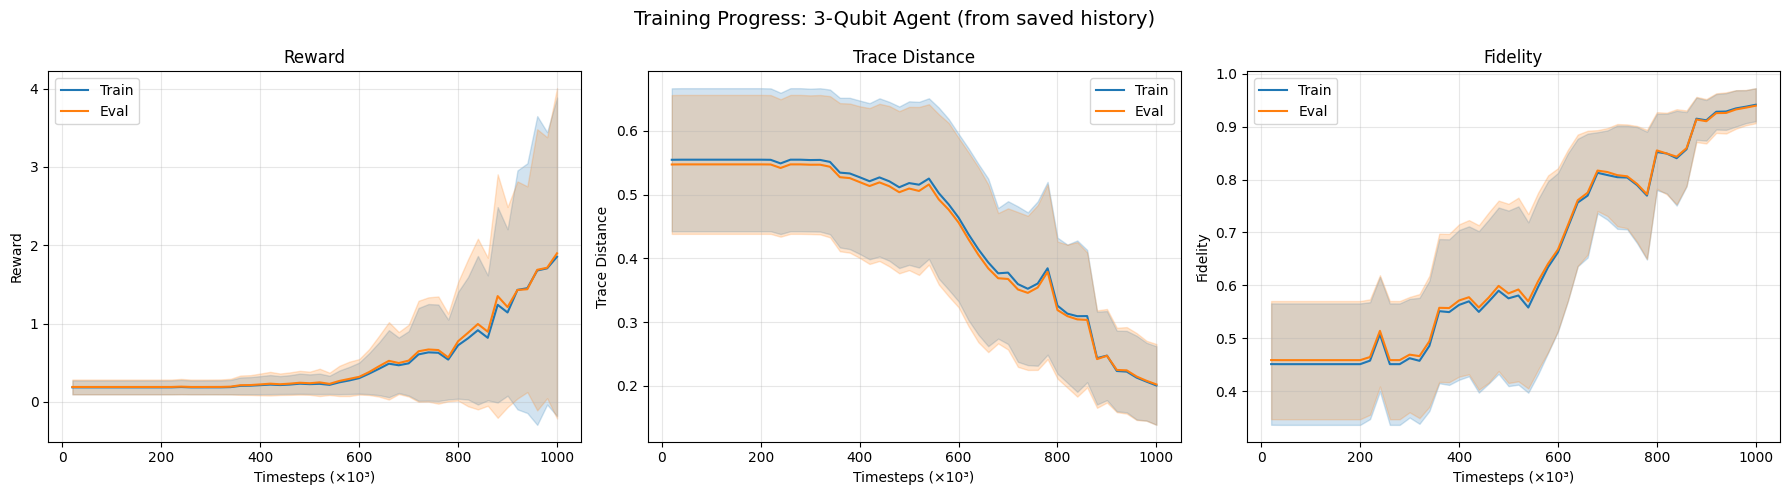


Reloaded dataset config : 
  DatasetConfig
    - Circuits:       800
    - Qubits:         3
    - Moments:        20
    - Type:           Mixed (Clifford + Arbitrary)
    - Gates:          [rz, rx, cz]

Reloaded agent config   : policy='MlpPolicy' features_dim=64 filter_size=1 n_filters=32 pi_net_arch=[32, 32] vf_net_arch=[32, 32] n_steps=2000 batch_size=400 learning_rate=0.0001 gamma=0.99 clip_range=0.2 verbose=1


In [9]:
from rlnoise.callback import TrainingCallback
from rlnoise.visualization import plot_training_dashboard
from rlnoise.config import ExperimentConfig

# ── Load history from disk (no re-training needed) ───────────────────────────
loaded_history = TrainingCallback.load_history("results/training/3q/history")

print(f"Loaded {len(loaded_history['timesteps'])} evaluation checkpoints")
print(f"Metric    : {loaded_history['metric_name']}")
print(f"Best reward: {loaded_history['best_mean_reward']:.4f}")
print(f"Qubits    : {loaded_history['n_qubits']}   "
      f"Train circuits: {loaded_history['n_circuits_train']}   "
      f"Val circuits: {loaded_history['n_circuits_val']}")

# ── Re-plot directly from the loaded dict ────────────────────────────────────
fig = plot_training_dashboard(
    loaded_history,
    title="Training Progress: 3-Qubit Agent (from saved history)",
    filepath="results/training/3q/dashboard_reloaded.png",
    show_reward=True,
    show_trace_distance=True,
    show_fidelity=True,
)
plt.show()

# ── Reload experiment configuration from JSON ─────────────────────────────────
reloaded_config = ExperimentConfig.from_json_file("results/training/3q/config.json")
print("\nReloaded dataset config :", reloaded_config.dataset)
print("Reloaded agent config   :", reloaded_config.agent)


### 5.7. Resume Training from a Checkpoint

To continue a previous run you need three things:
1. **Saved model weights** — the `.zip` file written via `save_path` (or `save_best`).
2. **Agent & environment config** — already in scope from the cells above.
3. **Previous history** *(optional)* — pass `previous_history` to `train()` and the new callback will be pre-populated with all earlier timestep/result data, so the combined history and any saved `.npz` span both runs seamlessly.


Output()

[Qibo 0.2.23|INFO|2026-04-21 13:07:18]: Using numpy backend on /CPU:0


Agent reloaded from 'agents/3q/model'.
Previous run: 50 checkpoints, best reward = 1.8972


Step 1020000 | Train reward: 1.5305 ± 1.7347  trace_dist: 0.2225 ± 0.0688  fidelity: 0.9290 ± 0.0369  |  Val reward: 1.5703 ± 1.7691  trace_dist: 0.2240 ± 0.0704  fidelity: 0.9270 ± 0.0378


Step 1040000 | Train reward: 1.8652 ± 1.9431  trace_dist: 0.1966 ± 0.0581  fidelity: 0.9430 ± 0.0287  |  Val reward: 1.9399 ± 2.1613  trace_dist: 0.1985 ± 0.0601  fidelity: 0.9407 ± 0.0313


...

Step 1940000 | Train reward: 6.2148 ± 4.1519  trace_dist: 0.1044 ± 0.0344  fidelity: 0.9825 ± 0.0128  |  Val reward: 6.2171 ± 4.0392  trace_dist: 0.1064 ± 0.0397  fidelity: 0.9818 ± 0.0145
Model saved in agents/3q/model_resumed


Step 1960000 | Train reward: 6.0743 ± 3.9575  trace_dist: 0.1052 ± 0.0343  fidelity: 0.9822 ± 0.0128  |  Val reward: 6.1183 ± 3.9158  trace_dist: 0.1070 ± 0.0393  fidelity: 0.9815 ± 0.0144


Step 1980000 | Train reward: 5.7461 ± 3.7904  trace_dist: 0.1079 ± 0.0343  fidelity: 0.9813 ± 0.0126  |  Val reward: 5.7643 ± 3.7792  trace_dist: 0.1099 ± 0.0394  fidelity: 0.9805 ± 0.0148


Step 2000000 | Train reward: 6.8954 ± 4.5821  trace_dist: 0.0990 ± 0.0325  fidelity: 0.9842 ± 0.0115  |  Val reward: 6.7852 ± 4.2732  trace_dist: 0.1008 ± 0.0359  fidelity: 0.9838 ± 0.0122
Model saved in agents/3q/model_resumed


Loaded best model weights from agents/3q/model_resumed
Training history saved to results/training/3q/history_resumed.npz

Resume complete — 50 old + 50 new checkpoints = 100 total.
Best reward overall: 6.7852


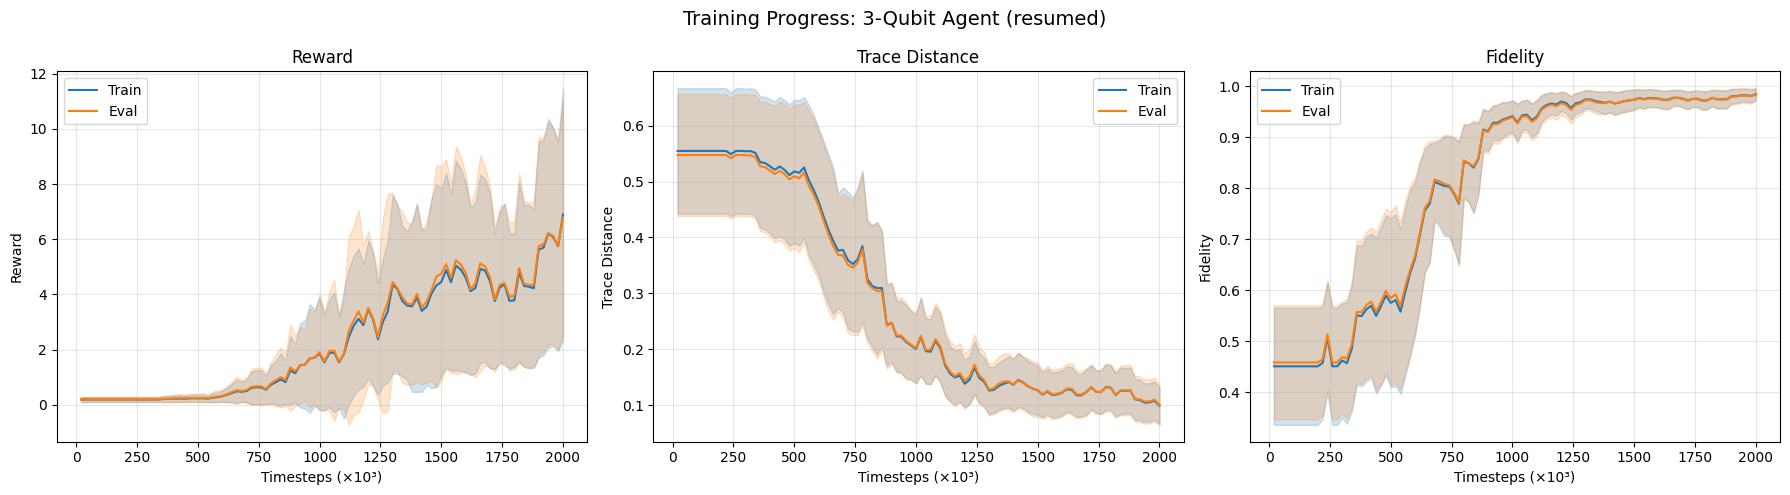

In [12]:

# ── 1. Reload the saved model weights ────────────────────────────────────────
resumed_agent = RLAgent(
    env=env_3q,
    agent_config=agent_config_3q,
    model_path="agents/3q/model",   # .zip written by the first training run
)
print("Agent reloaded from 'agents/3q/model'.")

# ── 2. Load the previous training history ────────────────────────────────────
prev_history = TrainingCallback.load_history("results/training/3q/history")
print(f"Previous run: {len(prev_history['timesteps'])} checkpoints, "
      f"best reward = {prev_history['best_mean_reward']:.4f}")

# ── 3. Resume training ────────────────────────────────────────────────────────
results_resumed = resumed_agent.train(
    total_timesteps=1000000,
    check_freq=20000,
    save_best=True,
    progress_bar=True,
    verbose=True,
    save_path="agents/3q/model_resumed",
    history_path="results/training/3q/history_resumed",
    previous_history=prev_history,
)

n_old = len(prev_history["timesteps"])
n_new = len(results_resumed["timesteps"]) - n_old
print(f"\nResume complete — {n_old} old + {n_new} new checkpoints "
      f"= {len(results_resumed['timesteps'])} total.")
print(f"Best reward overall: {results_resumed['best_mean_reward']:.4f}")

# ── 4. Plot the full combined training curve ──────────────────────────────────
fig = plot_training_dashboard(
    results_resumed,
    title="Training Progress: 3-Qubit Agent (resumed)",
    filepath="results/training/3q/dashboard_resumed.png",
    show_reward=True,
    show_trace_distance=True,
    show_fidelity=True,
)
plt.show()


### 5.8. Evaluation on Non-Clifford Test Circuits

Held-out evaluation on fresh non-Clifford random circuits, matching the end-of-training evaluation protocol from the original paper (see `old/src/rlnoise/rl_agent.py → apply_eval_dataset`).

In [23]:
from rlnoise.benchmarking import evaluate_on_dataset

# ── Parameters — adjust as needed ────────────────────────────────────────────
EVAL_N_CIRCUITS_3Q = 100   # number of non-Clifford test circuits
EVAL_DEPTH_3Q      = 15    # circuit depth (moments) — paper used eval_depth=15

# ── Generate fresh non-Clifford test circuits ─────────────────────────────────
eval_dataset_config_3q = DatasetConfig(
    n_circuits=EVAL_N_CIRCUITS_3Q,
    moments=EVAL_DEPTH_3Q,
    qubits=3,
    primitive_gates=["rz", "rx", "cz"],
    clifford=False,   # non-Clifford test set
    mixed=False,
)

from rlnoise.dataset import DatasetGenerator
eval_generator_3q = DatasetGenerator(eval_dataset_config_3q, noise_config_3q)
eval_dataset_3q = eval_generator_3q.generate(verbose=False)
print(f"Generated {EVAL_N_CIRCUITS_3Q} non-Clifford evaluation circuits "
      f"(depth={EVAL_DEPTH_3Q}, qubits=3)")

# ── Run evaluation ─────────────────────────────────────────────────────────────
eval_results_3q = evaluate_on_dataset(
    rl_agent=agent_3q,
    circuits=eval_dataset_3q.circuits,
    labels=eval_dataset_3q.labels,
    verbose=True,
)

Generated 100 non-Clifford evaluation circuits (depth=15, qubits=3)
  Evaluating circuit 1/100…
  Evaluating circuit 11/100…
  Evaluating circuit 21/100…
  Evaluating circuit 31/100…
  Evaluating circuit 41/100…
  Evaluating circuit 51/100…
  Evaluating circuit 61/100…
  Evaluating circuit 71/100…
  Evaluating circuit 81/100…
  Evaluating circuit 91/100…

  Evaluation Results (non-Clifford test set)
  Circuits evaluated : 100
  Fidelity           : 0.9556 ± 0.0331
  Trace distance     : 0.1510 ± 0.0580
  MSE                : 0.000487 ± 0.000397


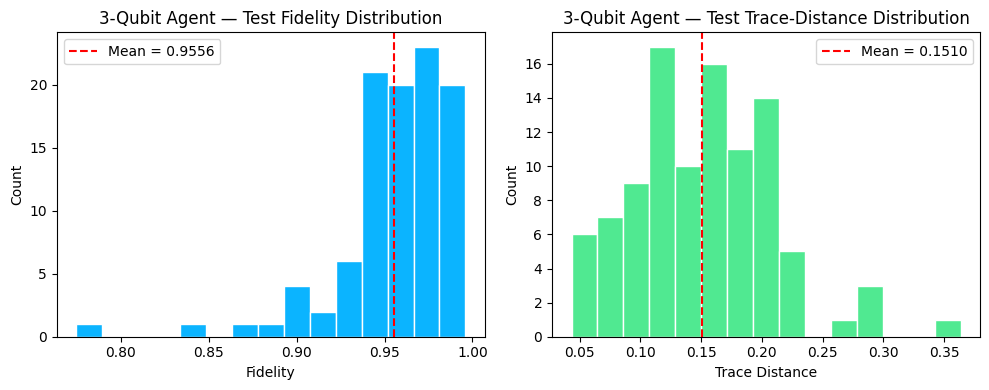

In [24]:
fidelities_3q  = [r["fidelity"]        for r in eval_results_3q["per_circuit"]]
trace_dists_3q = [r["trace_distance"]  for r in eval_results_3q["per_circuit"]]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(fidelities_3q, bins=15, color="#0bb4ff", edgecolor="white")
axes[0].axvline(eval_results_3q["mean_fidelity"], color="red", linestyle="--",
                label=f"Mean = {eval_results_3q['mean_fidelity']:.4f}")
axes[0].set_xlabel("Fidelity")
axes[0].set_ylabel("Count")
axes[0].set_title("3-Qubit Agent — Test Fidelity Distribution")
axes[0].legend()

axes[1].hist(trace_dists_3q, bins=15, color="#50e991", edgecolor="white")
axes[1].axvline(eval_results_3q["mean_trace_distance"], color="red", linestyle="--",
                label=f"Mean = {eval_results_3q['mean_trace_distance']:.4f}")
axes[1].set_xlabel("Trace Distance")
axes[1].set_ylabel("Count")
axes[1].set_title("3-Qubit Agent — Test Trace-Distance Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/training/3q/eval_distributions.png", dpi=150)
plt.show()

### 5.10. Load and Apply Trained Agent to Circuits


In [25]:
SAVE_PATH = "agents/3q/model"  # same path used in the training cell above

# ── 1. Load the saved agent ──────────────────────────────────────────────────
loaded_agent = RLAgent(
    env=env_3q,
    agent_config=agent_config_3q,
    model_path=SAVE_PATH,
)
print(f"Agent loaded from '{SAVE_PATH}'")

# ── 2. Pick a test circuit (first validation circuit) ────────────────────────
test_circuit_idx = env_3q.n_circuits_train
circuit_array    = dataset_3q.circuits[test_circuit_idx]
print(f"Test circuit index: {test_circuit_idx}  shape: {circuit_array.shape}")

# ── 3. Run a deterministic episode, recording actions per moment ─────────────
NOISE_LABELS = ["ε_x", "ε_z", "p_reset", "λ_depol"]
action_max    = env_3q.action_max
n_qubits      = env_3q.n_qubits

obs, _ = env_3q.reset(options={"circuit_idx": test_circuit_idx})
moment_actions = []
terminated = False
moment = 0

while not terminated:
    action = loaded_agent.predict(obs, deterministic=True)
    moment_actions.append((moment, action * action_max))
    obs, reward, terminated, truncated, info = env_3q.step(action)
    moment += 1

# ── 4. Print a table for the first 3 moments ─────────────────────────────────
n_show = min(3, len(moment_actions))
col_w  = 10

header  = f"{'Moment':>7}  {'Qubit':>5}  " + "  ".join(f"{l:>{col_w}}" for l in NOISE_LABELS)
divider = "-" * len(header)

print(f"\nNoise actions for the first {n_show} moments (scaled values):")
print(divider)
print(header)
print(divider)
for m_idx, scaled_action in moment_actions[:n_show]:
    for q in range(n_qubits):
        values = "  ".join(f"{scaled_action[q, c]:>{col_w}.5f}" for c in range(4))
        qubit_label = f"q{q}"
        print(f"{m_idx:>7}  {qubit_label:>5}  {values}")
    print(divider)

print(f"\nFinal episode reward: {reward:.4f}")

Agent loaded from 'agents/3q/model'
Test circuit index: 640  shape: (40, 3, 8)

Noise actions for the first 3 moments (scaled values):
--------------------------------------------------------------
 Moment  Qubit         ε_x         ε_z     p_reset     λ_depol
--------------------------------------------------------------
      0     q0     0.00000     0.00000     0.00000     0.00000
      0     q1     0.00000     0.00000     0.00000     0.00000
      0     q2     0.00000     0.00000     0.00360     0.00000
--------------------------------------------------------------
      1     q0     0.00000     0.00000     0.00000     0.00000
      1     q1     0.00000     0.00000     0.00000     0.00000
      1     q2     0.00000     0.00000     0.00324     0.00000
--------------------------------------------------------------
      2     q0     0.00000     0.00000     0.00000     0.00000
      2     q1     0.00000     0.00000     0.00000     0.00000
      2     q2     0.00000     0.00000     0.0